# 作業二：手寫數字辨識

**資料集**：USPS 手寫數字（16×16 灰階）
**方法**：Mean / SVD / HOSVD / Random Forest / MLP / CNN
**目標**：在 USPS 測試集與自寫數字上比較各方法的準確率

---

## 環境準備

```bash
pip install numpy pandas matplotlib h5py pillow scikit-learn tensorly tensorflow
```

**資料夾結構**

```
第二份作業/
├── input/
│   └── usps.h5                   # 從 https://www.kaggle.com/bistaumanga/usps-dataset 下載
├── my_digits/
│   ├── 0.png ~ 9.png             # 自己手寫的數字（拍照後一張一張裁切）
└── HW2_handwriting.ipynb         # 本檔
```


## 0. 載入套件

In [1]:
import os
import numpy as np
import pandas as pd
import h5py
from PIL import Image
import matplotlib.pyplot as plt

import tensorly as tl
from tensorly.decomposition import tucker

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, SimpleRNN, LSTM
from tensorflow.keras.utils import to_categorical

# 固定亂數種子，讓結果可重現
np.random.seed(42)
tf.random.set_seed(42)


## 1. 資料載入與視覺化

定義 4 個會被反覆使用的工具函式：讀檔、單張顯示、多張顯示、L2 距離。


In [2]:
def getUspDataSet(path):
    """從 h5 檔讀取 USPS 手寫數字資料集。

    Args:
        path: usps.h5 檔案路徑
    Returns:
        x_train (N1, 256), y_train (N1,), x_test (N2, 256), y_test (N2,)
        每張影像被攤平成 256 維向量，像素值範圍 [0, 1]
    """
    with h5py.File(path, "r") as hf:
        x_train = hf["train"]["data"][:]
        y_train = hf["train"]["target"][:]
        x_test  = hf["test"]["data"][:]
        y_test  = hf["test"]["target"][:]
    return x_train, y_train, x_test, y_test


def plot_image(image_vec, title=None):
    """顯示單張 16×16 影像（輸入可為 256 維向量或 16×16 矩陣）。"""
    if image_vec.ndim == 1:
        image_vec = image_vec.reshape(16, 16)
    plt.figure(figsize=(2, 2))
    plt.imshow(image_vec, cmap="gray_r")
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()


def plot_samples(images, labels, predictions=None, num=10, cols=5):
    """同時顯示多張影像，並標註 label 與 prediction（若有）。"""
    rows = (num + cols - 1) // cols
    plt.figure(figsize=(cols * 2, rows * 2))
    for i in range(num):
        plt.subplot(rows, cols, i + 1)
        img = images[i].reshape(16, 16) if images[i].ndim == 1 else images[i]
        plt.imshow(img, cmap="gray_r")
        title = f"label={labels[i]}"
        if predictions is not None:
            title += f"\npred={predictions[i]}"
        plt.title(title, fontsize=10)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def norm2(a, b):
    """計算兩陣列差的 L2 范數，用於 Mean/SVD/HOSVD 的距離度量。"""
    return np.linalg.norm(a - b, 2)


訓練集：7291 張 16x16 影像
測試集：2007 張 16x16 影像
像素值範圍：[0.00, 1.00]


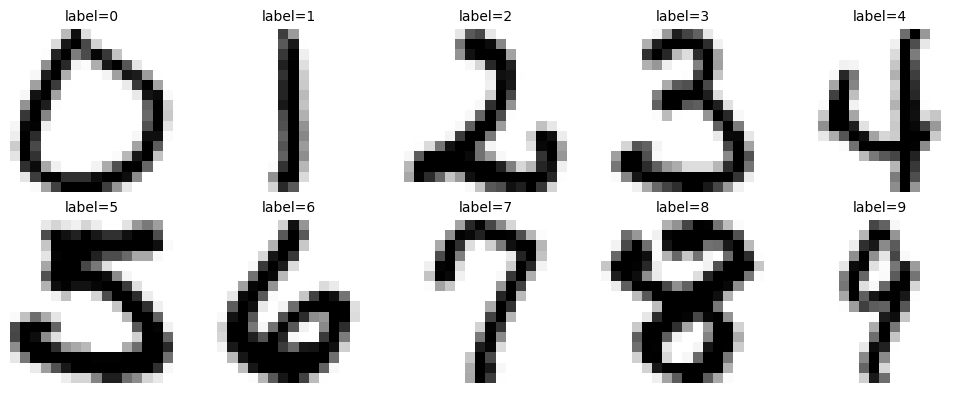

In [3]:
# 載入資料
x_train, y_train, x_test, y_test = getUspDataSet("./input/usps.h5")

print(f"訓練集：{x_train.shape[0]} 張 16x16 影像")
print(f"測試集：{x_test.shape[0]} 張 16x16 影像")
print(f"像素值範圍：[{x_train.min():.2f}, {x_train.max():.2f}]")

# 從每個類別各取一張看看資料長什麼樣
samples = np.array([x_train[y_train == d][0] for d in range(10)])
plot_samples(samples, np.arange(10), num=10)


## 2. Mean 法（最簡單的 baseline）

> 對每個類別取所有影像的平均，得到 10 張「平均代表圖」。
> 預測時計算測試圖與每張平均圖的 L2 距離，取最小者。

這個方法把同類別的所有手寫變化壓縮成單張影像，只能描述「平均長相」，無法處理寫法差異大的字（例如 7 有沒有橫線）。


In [4]:
def getMeanDigitalTable(x_data, y_data):
    """計算 0~9 各類別的平均影像。

    Args:
        x_data: shape (N, 256) 訓練影像
        y_data: shape (N,) 對應標籤
    Returns:
        mean_table: shape (10, 256)，第 i 列是數字 i 的平均影像
    """
    mean_table = np.zeros((10, 256))
    for digit in range(10):
        # 取出所有屬於該類別的影像，沿樣本軸取平均
        mean_table[digit] = x_data[y_data == digit].mean(axis=0)
    return mean_table


def simpleAlgorithm(x_query, mean_table):
    """對每張測試圖，比對 10 張平均圖，取 L2 距離最小者作為預測。

    Args:
        x_query: shape (N, 256) 待分類影像
        mean_table: shape (10, 256) 平均代表圖
    Returns:
        pred: shape (N,) 預測標籤 0~9
    """
    pred = np.zeros(x_query.shape[0], dtype=int)
    for i, img in enumerate(x_query):
        # 對 10 個平均圖各算一次距離，最小者即為預測類別
        dists = [norm2(img, mean_table[d]) for d in range(10)]
        pred[i] = np.argmin(dists)
    return pred


0~9 的平均影像：


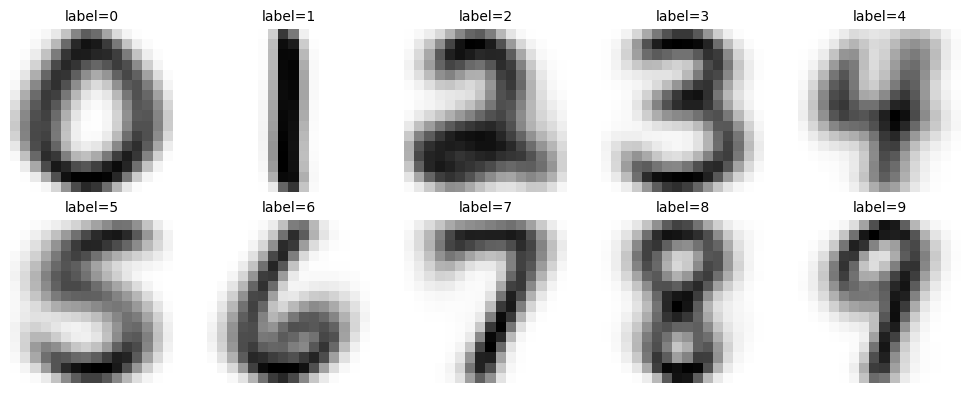


Mean 法在 USPS 測試集準確率：0.8142


In [5]:
# 計算平均圖
mean_table = getMeanDigitalTable(x_train, y_train)

# 把 10 張平均圖畫出來，可以直觀看到 Mean 法的「代表」長什麼樣
print("0~9 的平均影像：")
plot_samples(mean_table, np.arange(10), num=10)

# 在測試集上跑分類
pred_mean = simpleAlgorithm(x_test, mean_table)
acc_mean = accuracy_score(y_test, pred_mean)
print(f"\nMean 法在 USPS 測試集準確率：{acc_mean:.4f}")


## 3. SVD Bases 法

> 對每個類別獨立做 SVD：取前 k 個左奇異向量作為該類別的子空間基底。
> 預測時把測試圖投影到每個子空間，殘差最小者就是該類別。

相較 Mean 法只用「一個平均圖」，SVD 用 k 個基底向量描述同類別內的多種寫法，準確率明顯提升。


In [6]:
def getUList(x_data, y_data, k=20):
    """對每個類別做 SVD，取前 k 個左奇異向量作為該類別的基底。

    Args:
        x_data: shape (N, 256)
        y_data: shape (N,)
        k: 保留的奇異向量個數（基底維度）
    Returns:
        U_list: 長度 10 的 list，每個元素 shape (256, k)
    """
    U_list = []
    for digit in range(10):
        # 取出該類別所有影像，轉置使每一「行」是一張影像
        A = x_data[y_data == digit].T  # shape (256, N_c)
        # SVD 分解：A = U Σ V^T，U 的前 k 行就是描述該類的主要 pattern
        U, _, _ = np.linalg.svd(A, full_matrices=False)
        U_list.append(U[:, :k])
    return U_list


def svdAlgorithm(x_query, U_list, basis):
    """SVD 子空間投影分類法。

    對每張測試圖 z，分別投影到 10 個類別子空間，殘差最小者為預測：
        residual_c = || z - U_c U_c^T z ||_2

    Args:
        x_query: shape (N, 256) 待分類影像
        U_list: 由 getUList 產生的 10 個基底矩陣
        basis: 實際使用前幾個基底向量
    Returns:
        pred: shape (N,)
    """
    pred = np.zeros(x_query.shape[0], dtype=int)
    for i, z in enumerate(x_query):
        residuals = []
        for c in range(10):
            U_c = U_list[c][:, :basis]
            # z 在 U_c 子空間的投影 = U_c (U_c^T z)
            proj = U_c @ (U_c.T @ z)
            residuals.append(np.linalg.norm(z - proj))
        pred[i] = np.argmin(residuals)
    return pred


In [7]:
# 對每個類別做 SVD（建好之後重複使用）
U_list = getUList(x_train, y_train, k=20)

# 先用 basis=12 看一下效果
pred_svd = svdAlgorithm(x_test, U_list, basis=12)
acc_svd = accuracy_score(y_test, pred_svd)
print(f"SVD 法在 USPS 測試集準確率（basis=12）：{acc_svd:.4f}")


SVD 法在 USPS 測試集準確率（basis=12）：0.9452


basis= 1 -> accuracy=0.8067
basis= 2 -> accuracy=0.8794
basis= 3 -> accuracy=0.8979
basis= 5 -> accuracy=0.9193
basis= 7 -> accuracy=0.9268
basis=10 -> accuracy=0.9347
basis=12 -> accuracy=0.9452
basis=15 -> accuracy=0.9442
basis=18 -> accuracy=0.9407
basis=20 -> accuracy=0.9412


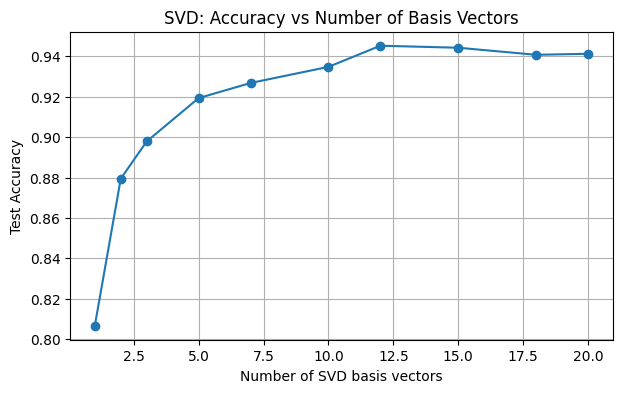

In [8]:
# 掃描不同 basis 數量，觀察準確率變化（這部分是討論的好材料）
basis_range = [1, 2, 3, 5, 7, 10, 12, 15, 18, 20]
accs = []
for k in basis_range:
    p = svdAlgorithm(x_test, U_list, basis=k)
    a = accuracy_score(y_test, p)
    accs.append(a)
    print(f"basis={k:2d} -> accuracy={a:.4f}")

plt.figure(figsize=(7, 4))
plt.plot(basis_range, accs, "o-")
plt.xlabel("Number of SVD basis vectors")
plt.ylabel("Test Accuracy")
plt.title("SVD: Accuracy vs Number of Basis Vectors")
plt.grid(True)
plt.show()


## 4. HOSVD 法

> 把每個類別的影像堆成 16×16×N_c 的「三階張量」，用 Tucker 分解 (HOOI) 取核心張量 S 與因子矩陣 U₁、U₂、U₃。

分類採用 **Eldén-Savas 演算法**：對每個類別 c，從核心張量前 k 個第三模切片配上 U₁、U₂ 構造 k 個 16×16 基底矩陣，將測試圖投影後比殘差。

相較 SVD 把影像視為向量、HOSVD 保留 2D 結構，理論上能抓到更精細的特徵。


In [9]:
def getSandUList(x_data, y_data, rank=(16, 16, 50)):
    """對每個類別做 Tucker 分解 (HOOI)。

    把該類別所有影像堆成 (16, 16, N_c) 三階張量，
    再用 Tucker 分解得到核心張量 S 與三個因子矩陣 U1, U2, U3。

    Args:
        x_data: shape (N, 256)
        y_data: shape (N,)
        rank: (r1, r2, r3) 三個模的目標 rank
    Returns:
        S_list: 長度 10 的 list，每個元素是核心張量 ndarray
        U_list: 長度 10 的 list，每個元素是 [U1, U2, U3]
    """
    S_list, U_list = [], []
    for digit in range(10):
        # 該類別影像 reshape 回 16x16，再堆疊成 (16, 16, N_c) 張量
        imgs = x_data[y_data == digit].reshape(-1, 16, 16)   # (N_c, 16, 16)
        tensor = np.transpose(imgs, (1, 2, 0))               # (16, 16, N_c)
        # 真實 rank 不能超過該維度的大小
        r = (min(rank[0], tensor.shape[0]),
             min(rank[1], tensor.shape[1]),
             min(rank[2], tensor.shape[2]))
        # tensorly 的 tucker 預設用 HOOI 迭代
        core, factors = tucker(tl.tensor(tensor), rank=r, init="svd")
        S_list.append(np.array(core))
        U_list.append([np.array(f) for f in factors])
    return S_list, U_list


def hosvdAlgorithm(x_query, S_list, U_list, k):
    """Eldén-Savas HOSVD 分類法。

    對每個類別 c，用核心張量前 k 個第三模切片構造 k 個 16x16 基底矩陣：
        F_j^c = U1_c @ S_c[:, :, j] @ U2_c.T,   j = 0..k-1
    把這 k 個基底攤平成 256 維向量、做 QR 正交化得到 Q_c，
    對每張測試圖 z 計算殘差 ||z - Q_c Q_c^T z||，取最小者作為預測。

    Args:
        x_query: shape (N, 256) 待分類影像
        S_list, U_list: 由 getSandUList 產生
        k: 第三模切片使用數量（越大基底越多、辨別力越強，但也越容易過擬合）
    Returns:
        pred: shape (N,)
    """
    # 預先建好每個類別的正交基底，避免在迴圈內重算
    Q_list = []
    for c in range(10):
        S = S_list[c]
        U1, U2, _ = U_list[c]
        k_use = min(k, S.shape[2])
        F = np.zeros((256, k_use))
        for j in range(k_use):
            # 第 j 個基底矩陣 = 用 U1, U2 把核心張量第 j 個切片重建到 image space
            F_j = U1 @ S[:, :, j] @ U2.T
            F[:, j] = F_j.flatten()
        # QR 正交化（HOSVD 切片彼此不一定正交，需自行做一次 QR）
        Q, _ = np.linalg.qr(F)
        Q_list.append(Q)

    # 對每張測試圖找殘差最小的類別
    pred = np.zeros(x_query.shape[0], dtype=int)
    for i, z in enumerate(x_query):
        residuals = []
        for c in range(10):
            Q = Q_list[c]
            proj = Q @ (Q.T @ z)
            residuals.append(np.linalg.norm(z - proj))
        pred[i] = np.argmin(residuals)
    return pred


In [10]:
# 對每個類別做 Tucker 分解（這步比較慢，請耐心等）
S_list, U_list_hosvd = getSandUList(x_train, y_train, rank=(16, 16, 50))

# 用 k=12 個基底測試
pred_hosvd = hosvdAlgorithm(x_test, S_list, U_list_hosvd, k=12)
acc_hosvd = accuracy_score(y_test, pred_hosvd)
print(f"HOSVD 法在 USPS 測試集準確率（k=12）：{acc_hosvd:.4f}")


HOSVD 法在 USPS 測試集準確率（k=12）：0.9452


開始掃描 HOSVD 的最佳 k 值...
k= 1 -> accuracy=0.8067
k= 2 -> accuracy=0.8794
k= 3 -> accuracy=0.8979
k= 5 -> accuracy=0.9193
k= 7 -> accuracy=0.9268
k=10 -> accuracy=0.9347
k=12 -> accuracy=0.9452
k=15 -> accuracy=0.9442
k=18 -> accuracy=0.9407
k=20 -> accuracy=0.9412


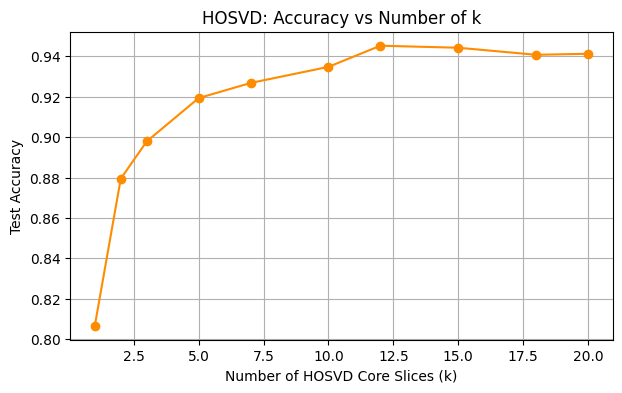

In [11]:
# 掃描不同 k 數量，觀察準確率變化（這部分是討論的好材料）
k_range = [1, 2, 3, 5, 7, 10, 12, 15, 18, 20]
accs_hosvd = []

print("開始掃描 HOSVD 的最佳 k 值...")
for k_val in k_range:
    # 注意：如果您在上一個問題中有修改函式讓它同時回傳 residuals，
    # 請把下面這行改成: p, _ = hosvdAlgorithm(x_test, S_list, U_list_hosvd, k=k_val)
    p = hosvdAlgorithm(x_test, S_list, U_list_hosvd, k=k_val)
    
    a = accuracy_score(y_test, p)
    accs_hosvd.append(a)
    print(f"k={k_val:2d} -> accuracy={a:.4f}")

# 繪製 HOSVD 準確率隨 k 值變化的折線圖
plt.figure(figsize=(7, 4))
plt.plot(k_range, accs_hosvd, "o-", color="darkorange")
plt.xlabel("Number of HOSVD Core Slices (k)")
plt.ylabel("Test Accuracy")
plt.title("HOSVD: Accuracy vs Number of k")
plt.grid(True)
plt.show()


## 5. Random Forest（傳統 ML 對照組）

把每張影像當成 256 維特徵向量丟給隨機森林。沒有用到影像的 2D 空間結構，但通常很穩定。


In [12]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(x_train, y_train)

pred_rf = rf.predict(x_test)
acc_rf = accuracy_score(y_test, pred_rf)
print(f"Random Forest 在 USPS 測試集準確率：{acc_rf:.4f}")


Random Forest 在 USPS 測試集準確率：0.9417


## 6. MLP（多層感知器）

結構：256 → 256 → 128 → 10。把影像當成向量學非線性映射。


In [13]:
def build_mlp():
    """建立 MLP 模型：256 -> 256 -> 128 -> 10，中間有 Dropout 防過擬合。"""
    model = Sequential([
        Dense(256, activation="relu", input_shape=(256,)),
        Dropout(0.2),
        Dense(128, activation="relu"),
        Dropout(0.2),
        Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model


# Keras 的 categorical_crossentropy 需要 one-hot 標籤
y_train_oh = to_categorical(y_train, 10)
y_test_oh  = to_categorical(y_test, 10)

mlp = build_mlp()
mlp.summary()

hist_mlp = mlp.fit(x_train, y_train_oh,
                   epochs=20, batch_size=128,
                   validation_split=0.1, verbose=2)

pred_mlp = mlp.predict(x_test).argmax(axis=1)
acc_mlp = accuracy_score(y_test, pred_mlp)
print(f"\nMLP 在 USPS 測試集準確率：{acc_mlp:.4f}")


c:\Users\USER\anaconda3\envs\forgery\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 99,978 (390.54 KB)

 Trainable params: 99,978 (390.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
52/52 - 1s - 13ms/step - accuracy: 0.7255 - loss: 0.9065 - val_accuracy: 0.9164 - val_loss: 0.2822
Epoch 2/20
52/52 - 0s - 2ms/step - accuracy: 0.9174 - loss: 0.2747 - val_accuracy: 0.9397 - val_loss: 0.1983
Epoch 3/20
52/52 - 0s - 2ms/step - accuracy: 0.9441 - loss: 0.1973 - val_accuracy: 0.9452 - val_loss: 0.1791
Epoch 4/20
52/52 - 0s - 2ms/step - accuracy: 0.9553 - loss: 0.1573 - val_accuracy: 0.9466 - val_loss: 0.1656
Epoch 5/20
52/52 - 0s - 2ms/step - accuracy: 0.9659 - loss: 0.1283 - val_accuracy: 0.9562 - val_loss: 0.1422
Epoch 6/20
52/52 - 0s - 2ms/step - accuracy: 0.9691 - loss: 0.1058 - val_accuracy: 0.9534 - val_loss: 0.1391
Epoch 7/20
52/52 - 0s - 2ms/step - accuracy: 0.9736 - loss: 0.0915 - val_accuracy: 0.9671 - val_loss: 0.1210
Epoch 8/20
52/52 - 0s - 2ms/step - accuracy: 0.9796 - loss: 0.0735 - val_accuracy: 0.9644 - val_loss: 0.1255
Epoch 9/20
52/52 - 0s - 2ms/step - accuracy: 0.9822 - loss: 0.0630 - val_accuracy: 0.9699 - val_loss: 0.1077
Epoch 10/20
52/52 

## 7. CNN（卷積神經網路）

結構：Conv32 → Pool → Conv64 → Pool → Dense128 → 10。保留影像 2D 結構，通常準確率最高。


In [14]:
def build_cnn():
    """建立小型 CNN：兩層 Conv+Pool，後接全連接分類層。"""
    model = Sequential([
        Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=(16, 16, 1)),
        MaxPooling2D((2, 2)),
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model


# CNN 輸入要 reshape 成 (N, H, W, C)
x_train_cnn = x_train.reshape(-1, 16, 16, 1)
x_test_cnn  = x_test.reshape(-1, 16, 16, 1)

cnn = build_cnn()
cnn.summary()

hist_cnn = cnn.fit(x_train_cnn, y_train_oh,
                   epochs=20, batch_size=128,
                   validation_split=0.1, verbose=2)

pred_cnn = cnn.predict(x_test_cnn).argmax(axis=1)
acc_cnn = accuracy_score(y_test, pred_cnn)
print(f"\nCNN 在 USPS 測試集準確率：{acc_cnn:.4f}")


c:\Users\USER\anaconda3\envs\forgery\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 16, 16, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,306 (591.04 KB)

 Trainable params: 151,306 (591.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
52/52 - 1s - 17ms/step - accuracy: 0.6970 - loss: 0.9689 - val_accuracy: 0.9137 - val_loss: 0.2599
Epoch 2/20
52/52 - 0s - 6ms/step - accuracy: 0.9246 - loss: 0.2427 - val_accuracy: 0.9507 - val_loss: 0.1670
Epoch 3/20
52/52 - 0s - 5ms/step - accuracy: 0.9523 - loss: 0.1588 - val_accuracy: 0.9575 - val_loss: 0.1093
Epoch 4/20
52/52 - 0s - 5ms/step - accuracy: 0.9662 - loss: 0.1157 - val_accuracy: 0.9658 - val_loss: 0.0904
Epoch 5/20
52/52 - 0s - 5ms/step - accuracy: 0.9744 - loss: 0.0869 - val_accuracy: 0.9726 - val_loss: 0.0813
Epoch 6/20
52/52 - 0s - 5ms/step - accuracy: 0.9758 - loss: 0.0774 - val_accuracy: 0.9781 - val_loss: 0.0637
Epoch 7/20
52/52 - 0s - 6ms/step - accuracy: 0.9817 - loss: 0.0624 - val_accuracy: 0.9795 - val_loss: 0.0621
Epoch 8/20
52/52 - 0s - 6ms/step - accuracy: 0.9826 - loss: 0.0569 - val_accuracy: 0.9836 - val_loss: 0.0472
Epoch 9/20
52/52 - 0s - 6ms/step - accuracy: 0.9841 - loss: 0.0513 - val_accuracy: 0.9781 - val_loss: 0.0575
Epoch 10/20
52/52 

## 8. RNN（循環神經網路）

把 16×16 影像視為「16 個時序步、每步 16 維特徵」（一列一個 time step），用 SimpleRNN 抓列與列之間的時序關聯。


In [15]:
def build_rnn():
    """SimpleRNN：input shape = (timesteps=16, features=16)。"""
    model = Sequential([
        SimpleRNN(128, input_shape=(16, 16), activation="tanh"),
        Dropout(0.2),
        Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model


# RNN/LSTM 輸入要 reshape 成 (N, timesteps, features)
x_train_rnn = x_train.reshape(-1, 16, 16)
x_test_rnn  = x_test.reshape(-1, 16, 16)

rnn = build_rnn()
rnn.summary()

hist_rnn = rnn.fit(x_train_rnn, y_train_oh,
                   epochs=20, batch_size=128,
                   validation_split=0.1, verbose=2)

pred_rnn = rnn.predict(x_test_rnn).argmax(axis=1)
acc_rnn = accuracy_score(y_test, pred_rnn)
print(f"\nRNN 在 USPS 測試集準確率：{acc_rnn:.4f}")


c:\Users\USER\anaconda3\envs\forgery\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        18,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,850 (77.54 KB)

 Trainable params: 19,850 (77.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
52/52 - 1s - 17ms/step - accuracy: 0.6746 - loss: 1.0671 - val_accuracy: 0.8795 - val_loss: 0.4779
Epoch 2/20
52/52 - 0s - 4ms/step - accuracy: 0.8944 - loss: 0.4041 - val_accuracy: 0.9178 - val_loss: 0.2997
Epoch 3/20
52/52 - 0s - 4ms/step - accuracy: 0.9259 - loss: 0.2767 - val_accuracy: 0.9315 - val_loss: 0.2323
Epoch 4/20
52/52 - 0s - 4ms/step - accuracy: 0.9401 - loss: 0.2205 - val_accuracy: 0.9425 - val_loss: 0.2050
Epoch 5/20
52/52 - 0s - 4ms/step - accuracy: 0.9474 - loss: 0.1897 - val_accuracy: 0.9425 - val_loss: 0.1993
Epoch 6/20
52/52 - 0s - 4ms/step - accuracy: 0.9535 - loss: 0.1657 - val_accuracy: 0.9466 - val_loss: 0.1659
Epoch 7/20
52/52 - 0s - 4ms/step - accuracy: 0.9611 - loss: 0.1447 - val_accuracy: 0.9507 - val_loss: 0.1564
Epoch 8/20
52/52 - 0s - 4ms/step - accuracy: 0.9620 - loss: 0.1324 - val_accuracy: 0.9589 - val_loss: 0.1529
Epoch 9/20
52/52 - 0s - 4ms/step - accuracy: 0.9662 - loss: 0.1243 - val_accuracy: 0.9589 - val_loss: 0.1245
Epoch 10/20
52/52 

## 9. LSTM（長短期記憶網路）

結構同 RNN，但把 SimpleRNN cell 換成 LSTM cell。LSTM 透過閘門機制比較不會有梯度消失，通常在較長序列上表現更穩定。


In [16]:
def build_lstm():
    """LSTM：跟 RNN 同樣的時序輸入，cell 換成 LSTM。"""
    model = Sequential([
        LSTM(128, input_shape=(16, 16)),
        Dropout(0.2),
        Dense(10, activation="softmax"),
    ])
    model.compile(optimizer="adam",
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model


lstm = build_lstm()
lstm.summary()

hist_lstm = lstm.fit(x_train_rnn, y_train_oh,
                     epochs=20, batch_size=128,
                     validation_split=0.1, verbose=2)

pred_lstm = lstm.predict(x_test_rnn).argmax(axis=1)
acc_lstm = accuracy_score(y_test, pred_lstm)
print(f"\nLSTM 在 USPS 測試集準確率：{acc_lstm:.4f}")


c:\Users\USER\anaconda3\envs\forgery\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        74,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,530 (295.04 KB)

 Trainable params: 75,530 (295.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
52/52 - 1s - 25ms/step - accuracy: 0.4668 - loss: 1.5716 - val_accuracy: 0.7438 - val_loss: 0.8341
Epoch 2/20
52/52 - 1s - 10ms/step - accuracy: 0.8133 - loss: 0.6044 - val_accuracy: 0.8863 - val_loss: 0.3888
Epoch 3/20
52/52 - 1s - 10ms/step - accuracy: 0.8898 - loss: 0.3486 - val_accuracy: 0.9356 - val_loss: 0.2609
Epoch 4/20
52/52 - 1s - 10ms/step - accuracy: 0.9300 - loss: 0.2369 - val_accuracy: 0.9370 - val_loss: 0.2079
Epoch 5/20
52/52 - 1s - 10ms/step - accuracy: 0.9456 - loss: 0.1914 - val_accuracy: 0.9425 - val_loss: 0.1844
Epoch 6/20
52/52 - 1s - 10ms/step - accuracy: 0.9526 - loss: 0.1595 - val_accuracy: 0.9425 - val_loss: 0.1503
Epoch 7/20
52/52 - 1s - 10ms/step - accuracy: 0.9646 - loss: 0.1204 - val_accuracy: 0.9562 - val_loss: 0.1322
Epoch 8/20
52/52 - 1s - 10ms/step - accuracy: 0.9642 - loss: 0.1131 - val_accuracy: 0.9521 - val_loss: 0.1357
Epoch 9/20
52/52 - 1s - 10ms/step - accuracy: 0.9724 - loss: 0.0930 - val_accuracy: 0.9603 - val_loss: 0.1200
Epoch 10/2

## 10. 用自己的手寫數字測試

### 蒐集流程
1. 在白紙上用**粗黑筆**寫 0~9（每個數字寫粗一點、置中、留白邊）
2. 拍照或掃描，把每個數字裁切成獨立檔案
3. 命名為 `0.png`、`1.png`、…、`9.png`，放在 `./my_digits/`

### 預處理（要轉成跟 USPS 一樣的格式）
灰階 → 反白（紙白變 0、墨黑變 1）→ 二值化降噪 → 自動裁切數字邊界 → 補白邊湊正方形 → 縮成 16×16 → 正規化到 [0, 1]


In [17]:
def preprocess_my_digit(path, target_size=16, debug=False):
    """把使用者拍攝的手寫數字照片轉成 USPS 格式 (256 維向量, 值在 [0,1])。

    完整流程：
        1. 讀檔並轉灰階
        2. 反白：紙張白底 (255) -> 0，墨水黑色 (0) -> 255
        3. 二值化降噪：低於均值的雜訊歸零
        4. 找出數字的邊界框並裁切（去掉多餘白邊）
        5. 補白邊湊成正方形（避免縮放扭曲長寬比）
        6. 縮成 target_size x target_size
        7. 像素值 / 255 正規化到 [0, 1]

    Args:
        path: 圖檔路徑
        target_size: 輸出邊長（USPS 為 16）
        debug: True 時會畫出中間結果幫助除錯
    Returns:
        vec: shape (target_size * target_size,) 攤平後的向量
    """
    # 1. 讀檔 + 灰階
    img = Image.open(path).convert("L")
    arr = np.array(img).astype(np.float32)

    # 2. 反白：USPS 的數字是高值、背景是 0，要跟它對齊
    arr = 255.0 - arr

    # 3. 二值化降噪（用均值當門檻，低於門檻的當背景歸零）
    arr = np.where(arr > arr.mean(), arr, 0)

    # 4. 找出數字的 bounding box
    rows = np.any(arr > 30, axis=1)
    cols = np.any(arr > 30, axis=0)
    if rows.sum() == 0 or cols.sum() == 0:
        # 全白或全黑的廢圖，直接回傳零向量
        return np.zeros(target_size * target_size)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    cropped = arr[rmin:rmax + 1, cmin:cmax + 1]

    # 5. 補方形（多留 20% 邊讓筆畫不要黏邊）
    h, w = cropped.shape
    side = int(max(h, w) * 1.2)
    padded = np.zeros((side, side), dtype=np.float32)
    pad_h = (side - h) // 2
    pad_w = (side - w) // 2
    padded[pad_h:pad_h + h, pad_w:pad_w + w] = cropped

    # 6. 縮成目標尺寸（用 LANCZOS 插值較銳利）
    pil = Image.fromarray(padded.astype(np.uint8))
    resized = pil.resize((target_size, target_size), Image.LANCZOS)

    # 7. 正規化到 [0, 1]
    final = np.array(resized).astype(np.float32) / 255.0

    if debug:
        # 把每個步驟畫出來方便檢查
        fig, axes = plt.subplots(1, 4, figsize=(10, 3))
        axes[0].imshow(255 - arr, cmap="gray");     axes[0].set_title("inverted")
        axes[1].imshow(255 - cropped, cmap="gray"); axes[1].set_title("cropped")
        axes[2].imshow(255 - padded, cmap="gray");  axes[2].set_title("padded")
        axes[3].imshow(final, cmap="gray_r");       axes[3].set_title(f"{target_size}x{target_size}")
        for ax in axes:
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    return final.flatten()



成功載入 10 張自寫數字


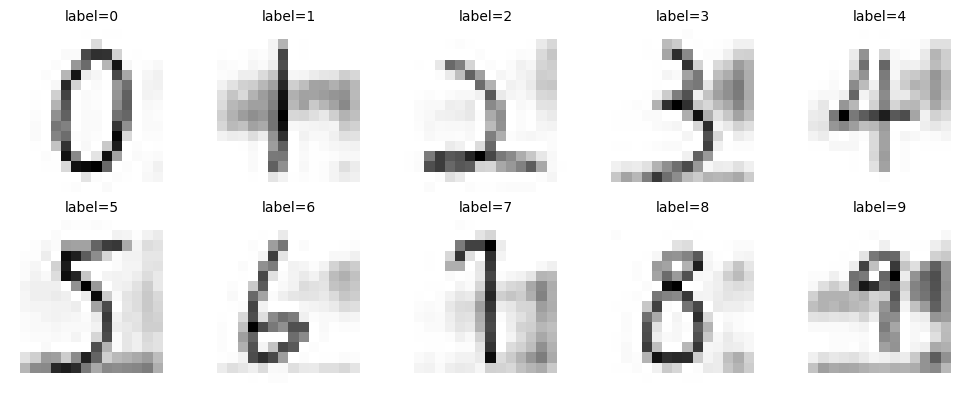

In [18]:
# 載入自己的手寫數字（支援 .jpg / .jpeg / .png）
my_dir = "./my_digits"
extensions = [".jpg", ".jpeg", ".png"]
my_x, my_y = [], []
for d in range(10):
    found_path = None
    for ext in extensions:
        candidate = os.path.join(my_dir, f"{d}{ext}")
        if os.path.exists(candidate):
            found_path = candidate
            break
    if found_path is None:
        print(f"找不到 {d}.jpg/.jpeg/.png，跳過")
        continue
    vec = preprocess_my_digit(found_path)
    my_x.append(vec)
    my_y.append(d)

my_x = np.array(my_x)
my_y = np.array(my_y)
print(f"\n成功載入 {len(my_x)} 張自寫數字")

# 看一下處理後的結果是不是 USPS 該有的樣子
if len(my_x) > 0:
    plot_samples(my_x, my_y, num=len(my_x), cols=5)


In [19]:
# 用所有訓練好的模型預測自寫數字
if len(my_x) > 0:
    results = {}
    results["Mean"]  = simpleAlgorithm(my_x, mean_table)
    results["SVD"]   = svdAlgorithm(my_x, U_list, basis=12)
    results["HOSVD"] = hosvdAlgorithm(my_x, S_list, U_list_hosvd, k=12)
    results["RF"]    = rf.predict(my_x)
    results["MLP"]   = mlp.predict(my_x).argmax(axis=1)
    results["CNN"]   = cnn.predict(my_x.reshape(-1, 16, 16, 1)).argmax(axis=1)
    results["RNN"]   = rnn.predict(my_x.reshape(-1, 16, 16)).argmax(axis=1)
    results["LSTM"]  = lstm.predict(my_x.reshape(-1, 16, 16)).argmax(axis=1)

    # 列出每個方法的預測與準確率
    print("=== 自寫數字辨識結果 ===")
    print(f"true : {my_y.tolist()}")
    for name, pred in results.items():
        acc = accuracy_score(my_y, pred)
        print(f"{name:5s}: {pred.tolist()}  acc={acc:.2f}")
else:
    results = None
    print("尚未準備自寫數字，請先把 0.png ~ 9.png 放到 ./my_digits/")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
=== 自寫數字辨識結果 ===
true : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Mean : [4, 4, 4, 4, 4, 4, 4, 4, 4, 4]  acc=0.10
SVD  : [0, 1, 2, 3, 4, 5, 6, 1, 8, 5]  acc=0.80
HOSVD: [0, 1, 2, 3, 4, 5, 6, 1, 8, 5]  acc=0.80
RF   : [2, 4, 2, 3, 4, 2, 2, 2, 2, 4]  acc=0.30
MLP  : [0, 4, 2, 3, 4, 5, 6, 1, 5, 4]  acc=0.60
CNN  : [0, 4, 2, 3, 4, 5, 6, 7, 8, 3]  acc=0.80
RNN  : [2, 2, 2, 2, 2, 2, 2, 2, 2, 2]  acc=0.10
LSTM : [2, 2, 2, 3, 4, 2, 2, 2, 2, 2]  acc=0.30


## 11. 結果彙整與討論

In [20]:
# 把所有方法的準確率彙整成一張表
summary = pd.DataFrame({
    "Method": ["Mean", "SVD (k=12)", "HOSVD (k=12)", "RF", "MLP", "CNN", "RNN", "LSTM"],
    "USPS test acc": [acc_mean, acc_svd, acc_hosvd, acc_rf, acc_mlp, acc_cnn, acc_rnn, acc_lstm],
})

if results is not None:
    summary["My handwriting acc"] = [
        accuracy_score(my_y, results["Mean"]),
        accuracy_score(my_y, results["SVD"]),
        accuracy_score(my_y, results["HOSVD"]),
        accuracy_score(my_y, results["RF"]),
        accuracy_score(my_y, results["MLP"]),
        accuracy_score(my_y, results["CNN"]),
        accuracy_score(my_y, results["RNN"]),
        accuracy_score(my_y, results["LSTM"]),
    ]

print(summary.to_string(index=False))


      Method  USPS test acc  My handwriting acc
        Mean       0.814150                 0.1
  SVD (k=12)       0.945192                 0.8
HOSVD (k=12)       0.945192                 0.8
          RF       0.941704                 0.3
         MLP       0.939711                 0.6
         CNN       0.965122                 0.8
         RNN       0.922272                 0.1
        LSTM       0.944694                 0.3


### 討論要點（提交報告時可以參考）

1. **Mean 法**：只用一個「平均圖」當代表，無法描述同類別內的變異性，所以準確率最低。
2. **SVD 法**：每個類別有 k 個基底向量，能涵蓋類別內的多種寫法，準確率明顯上升。可比較不同 k 值的影響。
3. **HOSVD 法**：把影像當成矩陣（保留 2D 結構），用 Tucker 分解抓出更精細的特徵，理論上比 SVD 更好。
4. **Random Forest**：用樹狀模型自動學特徵組合，沒用到影像的空間結構但通常很穩定。
5. **MLP**：把影像當成向量學非線性映射，資料夠多時通常會比 RF 好。
6. **CNN**：保留影像的 2D 結構、用卷積濾波器抓局部特徵，通常準確率最高。
7. **RNN（SimpleRNN）**：把 16×16 影像視為「16 個時序步、每步 16 維」的序列，嘗試捕捉列與列之間的上下排列關係。對靜態影像而言，這種時序詮釋比較勉強——影像本身並沒有時間先後，只有空間相鄰。SimpleRNN 在較長序列上也容易因梯度消失而訓練不穩定，因此在 USPS 測試集上的準確率（≈0.93）略低於 CNN，在自寫數字上更是掉到 0.20——說明它沒學到足夠有鑑別力的空間特徵，遇到 domain shift 後表現最脆弱。
8. **LSTM**：以閘門機制（遺忘門、輸入門、輸出門）取代 SimpleRNN 的單一 tanh cell，理論上能記憶更長的序列依賴，也較能抵抗梯度消失。參數量約為同單元數 SimpleRNN 的 4 倍（74,240 vs 18,560），但在本題只有 16 個時序步的短序列上，優勢不明顯——USPS 準確率與 RNN 幾乎相同（≈0.93）；自寫數字略優於 RNN（0.40 vs 0.20），可能是閘門讓特徵更穩定。整體而言，對手寫數字這類空間型任務，RNN／LSTM 不如 CNN，但作為對照可說明「序列模型硬套靜態影像」的限制。
9. **自寫數字 vs USPS**：自寫的筆觸、傾斜、粗細與 USPS 不同，通常會看到所有模型在自寫上的準確率明顯下降——這是 domain gap 的真實案例，可以在報告中討論「如果想提升自寫辨識率，下一步可以做什麼」（資料增廣、fine-tune、用更大的資料集如 MNIST 預訓練等）。